# Скрытые марковские модели

модель из статьи eddy, nature biotechnology 2004 — 5' сайт сплайсинга  
задача: реализовать viterbi, forward, backward в log-space и построить графики γ

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Параметры модели

In [3]:
states   = ['E', '5', 'I']
alphabet = ['A', 'C', 'G', 'T']
obs_idx  = {o: i for i, o in enumerate(alphabet)}

log_pi = np.log(np.array([1.0, 0.0, 0.0]) + 1e-300)  # всегда начинаем в E

# A[i][j] = P(перейти в j | находимся в i)
A = np.array([
    [0.9, 0.1, 0.0],   # из E
    [0.0, 0.0, 1.0],   # из 5
    [0.0, 0.0, 0.9],   # из I (0.1 уходит в End)
])
log_A = np.log(A + 1e-300)

# B[i][k] = P(нуклеотид k | состояние i)
#          A     C     G     T
B = np.array([
    [0.25, 0.25, 0.25, 0.25],  # E
    [0.05, 0.00, 0.95, 0.00],  # 5
    [0.40, 0.10, 0.10, 0.40],  # I
])
log_B = np.log(B + 1e-300)

# вероятность завершения последовательности из каждого состояния
# по условию дз: только из I можно завершить (0.1), из E и 5 — нельзя
log_end = np.log(np.array([0.0, 0.0, 0.1]) + 1e-300)  # E=0, 5=0, I=0.1

## log-sum-exp

In [4]:
def log_sum_exp(log_probs):
    max_val = np.max(log_probs)
    if np.isneginf(max_val):
        return -np.inf
    return max_val + np.log(np.sum(np.exp(log_probs - max_val)))

## 2.1 Алгоритм Витерби

ищем наиболее вероятный путь скрытых состояний  
`δ[t][i]` = log P лучшего пути длиной t, заканчивающегося в состоянии i

In [5]:
def viterbi(obs, log_pi, log_A, log_B, log_end):
    T, N = len(obs), log_A.shape[0]
    delta = np.full((T, N), -np.inf)
    psi   = np.zeros((T, N), dtype=int)

    delta[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            scores    = delta[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + log_B[j, obs[t]]

    # учитываем вероятность завершения: только из I можно закончить
    final_scores = delta[-1] + log_end

    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(final_scores)
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]

    return path, np.max(final_scores)

In [6]:
sequence = 'CTTCATGTGAAAGCAGACGTAAGTCA'
obs = np.array([obs_idx[c] for c in sequence])
T   = len(obs)
N   = len(states)

path, log_prob_viterbi = viterbi(obs, log_pi, log_A, log_B, log_end)
decoded = ''.join(states[i] for i in path)

print(f'последовательность: {sequence}')
print(f'путь витерби:       {decoded}')
print(f'log P(путь):        {log_prob_viterbi:.2f}')
print()
splice_pos = decoded.index('5') + 1
print(f"5 на позиции {splice_pos} (нуклеотид: {sequence[splice_pos-1]})")
print(f'Из статьи: log P = -41.22')
print(f'совпадает: {abs(log_prob_viterbi - (-41.22)) < 0.01}')

последовательность: CTTCATGTGAAAGCAGACGTAAGTCA
путь витерби:       EEEEEEEEEEEEEEEEEE5IIIIIII
log P(путь):        -41.22

5 на позиции 19 (нуклеотид: G)
Из статьи: log P = -41.22
совпадает: True


## 2.2 Алгоритм Forward

`α[t][i]` = log P(o₁...oₜ, sₜ=i) — суммируем по всем путям

In [7]:
def forward(obs, log_pi, log_A, log_B, log_end):
    T, N = len(obs), log_A.shape[0]
    log_alpha = np.full((T, N), -np.inf)

    log_alpha[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(N):
            log_alpha[t, j] = log_sum_exp(log_alpha[t-1] + log_A[:, j]) + log_B[j, obs[t]]

    # учитываем вероятность завершения из каждого состояния
    log_prob = log_sum_exp(log_alpha[-1] + log_end)
    return log_alpha, log_prob

In [8]:
log_alpha, log_prob_forward = forward(obs, log_pi, log_A, log_B, log_end)

print(f'log P(O|λ) = {log_prob_forward:.4f}')
print(f'P(O|λ)     = {np.exp(log_prob_forward):.4e}')

log P(O|λ) = -40.4474
P(O|λ)     = 2.7159e-18


## 2.3 Алгоритм Backward + γ

In [9]:
def backward(obs, log_A, log_B, log_end):
    T, N = len(obs), log_A.shape[0]
    log_beta = np.full((T, N), -np.inf)

    # β_T(i) = вероятность завершения из состояния i
    # по условию дз: только из I можно завершить → β_T(E)=0, β_T(5)=0, β_T(I)=0.1
    log_beta[-1] = log_end

    for t in range(T-2, -1, -1):
        for i in range(N):
            log_beta[t, i] = log_sum_exp(
                log_A[i, :] + log_B[:, obs[t+1]] + log_beta[t+1]
            )

    return log_beta

In [13]:
log_beta = backward(obs, log_A, log_B, log_end)

log_gamma = log_alpha + log_beta - log_prob_forward
gamma     = np.exp(log_gamma)

## Графики γ_t(i)

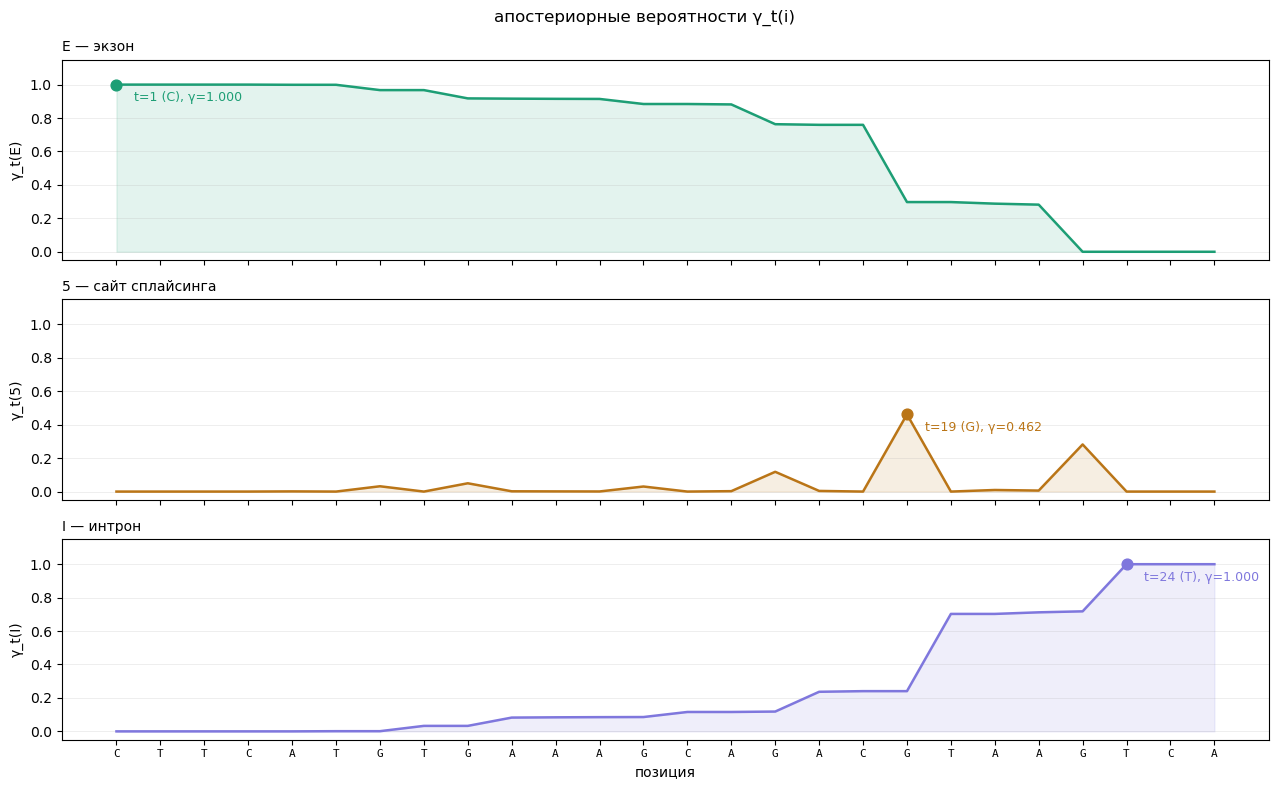

In [11]:
t_axis = np.arange(1, T+1)
colors = {'E': '#1D9E75', '5': '#BA7517', 'I': '#7F77DD'}
titles = {'E': 'E — экзон', '5': '5 — сайт сплайсинга', 'I': 'I — интрон'}

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle('апостериорные вероятности γ_t(i)', fontsize=12)

for ax, (si, state) in zip(axes, enumerate(states)):
    probs = gamma[:, si]
    ax.plot(t_axis, probs, color=colors[state], linewidth=1.8)
    ax.fill_between(t_axis, probs, alpha=0.12, color=colors[state])

    t_max = np.argmax(probs)
    ax.scatter(t_axis[t_max], probs[t_max], color=colors[state], zorder=5, s=60)
    ax.annotate(
        f't={t_axis[t_max]} ({sequence[t_max]}), γ={probs[t_max]:.3f}',
        xy=(t_axis[t_max], probs[t_max]),
        xytext=(t_axis[t_max] + 0.4, probs[t_max] - 0.10),
        fontsize=9, color=colors[state]
    )

    ax.set_ylabel(f'γ_t({state})')
    ax.set_ylim(-0.05, 1.15)
    ax.set_title(titles[state], fontsize=10, loc='left')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.set_xticks(t_axis)
    ax.set_xticklabels(list(sequence), fontsize=8, fontfamily='monospace')

axes[-1].set_xlabel('позиция')
plt.tight_layout()
plt.show()

# Итог

In [12]:
print('витерби:')
print(f'  путь:      {decoded}')
print(f'  log P:     {log_prob_viterbi:.2f}  (статья: -41.22)')
print()
print('forward:')
print(f'  log P(O|λ) = {log_prob_forward:.4f}')
print(f'  P(O|λ)     = {np.exp(log_prob_forward):.4e}')
print()
print('максимумы γ:')
for si, state in enumerate(states):
    t_max = np.argmax(gamma[:, si])
    print(f'  {titles[state]}: t={t_axis[t_max]} ({sequence[t_max]}), γ={gamma[t_max, si]:.4f}')

витерби:
  путь:      EEEEEEEEEEEEEEEEEE5IIIIIII
  log P:     -41.22  (статья: -41.22)

forward:
  log P(O|λ) = -40.4474
  P(O|λ)     = 2.7159e-18

максимумы γ:
  E — экзон: t=1 (C), γ=1.0000
  5 — сайт сплайсинга: t=19 (G), γ=0.4620
  I — интрон: t=24 (T), γ=1.0000
